# OVERVIEW

### Data preprocessing:
Transform the data into a suitable format for analysis.

### Correlation Analysis:
Analyze correlations between features.

### Linear Kernel SVM:
Train a linear kernel SVM and use it to conduct interpretable feature coefficient analysis.

### Heat Map Analysis:
Construct visual heat maps to identify conditions where fraud is more prevalent.

--

# DATA PREPROCESSING
For the Linear Kernel SVM:
- Train/test split: First 6 months for initial training, last 2 months for held-out testing
- Drop the ‘month’ column.
- Drop the 'device_fraud_count' column. It is a constant-valued column (useless)
- One-hot encoding of categorical columns
- Create indicator columns for columns with missing values
- Mean imputation of missing values
- Standardize features for coefficient interpretability

For the correlation analysis:
- Done on the same training dataset that linear kernel SVM uses

For heat map analysis:
- Done on the same training dataset that linear kernel SVM uses, but without feature standardization


In [2]:
import pandas as pd

df = pd.read_csv('Base.csv')

In [3]:
# data processing
mask = df["month"] <= 5
full_training_data = df[mask].sample(frac=1).reset_index(drop=True).drop('month',axis=1) # train on months 0 to 5. drop month as a feature
full_test_data = df[~mask].sample(frac=1).reset_index(drop=True).drop('month',axis=1) # test on months 6 and 7. drop month as a feature

# 'device_fraud_count' is literally a constant column. get rid of it.
full_training_data = full_training_data.drop('device_fraud_count', axis=1)
full_test_data = full_test_data.drop('device_fraud_count', axis=1)

print("Full training data # rows: " + str(full_training_data.shape[0]))
print("Full test data # rows: " + str(full_test_data.shape[0]))
print("Column list: " + str(full_training_data.columns))

Full training data # rows: 794989
Full test data # rows: 205011
Column list: Index(['fraud_bool', 'income', 'name_email_similarity',
       'prev_address_months_count', 'current_address_months_count',
       'customer_age', 'days_since_request', 'intended_balcon_amount',
       'payment_type', 'zip_count_4w', 'velocity_6h', 'velocity_24h',
       'velocity_4w', 'bank_branch_count_8w',
       'date_of_birth_distinct_emails_4w', 'employment_status',
       'credit_risk_score', 'email_is_free', 'housing_status',
       'phone_home_valid', 'phone_mobile_valid', 'bank_months_count',
       'has_other_cards', 'proposed_credit_limit', 'foreign_request', 'source',
       'session_length_in_minutes', 'device_os', 'keep_alive_session',
       'device_distinct_emails_8w'],
      dtype='object')


In [4]:
# more data processing
y_train_full = full_training_data["fraud_bool"]
X_train_full = full_training_data.drop("fraud_bool",axis=1)
y_test_full = full_test_data["fraud_bool"]
X_test_full = full_test_data.drop("fraud_bool",axis=1)

# percentage of 1's in y_train_full:
print("Fraction of 1's in y_train_full: " + str(y_train_full.mean()))

# make sure all numerical columns are actually stored numerically
y_train_full = y_train_full.astype(float)
y_test_full = y_test_full.astype(float)
for col in X_train_full.columns:
    converted = pd.to_numeric(X_train_full[col], errors='coerce')
    if converted.notna().sum() == X_train_full[col].notna().sum():
        X_train_full[col] = converted
for col in X_test_full.columns:
    converted = pd.to_numeric(X_test_full[col], errors='coerce')
    if converted.notna().sum() == X_test_full[col].notna().sum():
        X_test_full[col] = converted

categorical_cols = X_train_full.select_dtypes(exclude='number').columns.tolist()
print("Categorical columns: " + str(categorical_cols))

Fraction of 1's in y_train_full: 0.010252972053701372
Categorical columns: ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']


In [5]:
# one hot encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import numpy as np

ohe = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[("cat", ohe, categorical_cols)],
    remainder="passthrough"
)

preprocessor.set_output(transform="pandas")

X_train_full = preprocessor.fit_transform(X_train_full)
X_test_full  = preprocessor.transform(X_test_full)

In [6]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# Dealing with missing values
# the following columns have "-1" to indicate missing values: prev_address_months_count, current_address_months_count, bank_months_count, session_length_in_minutes

missing_cols = [
    "remainder__prev_address_months_count",
    "remainder__current_address_months_count",
    "remainder__bank_months_count",
    "remainder__session_length_in_minutes"
]

# 1a. Convert -1 to NaN in both train and test
X_train_full[missing_cols] = X_train_full[missing_cols].replace(-1, np.nan)
X_test_full[missing_cols] = X_test_full[missing_cols].replace(-1, np.nan)

# 1b. Create missing-value indicator columns (before imputation)
for col in missing_cols:
    indicator_name = f"{col}_is_missing"
    X_train_full[indicator_name] = X_train_full[col].isna().astype(int)
    X_test_full[indicator_name] = X_test_full[col].isna().astype(int)

# create 2 numpy arrays storing the mean and sd of each column (not counting NaN values)
col_means = X_train_full.mean().to_numpy()
col_stds  = X_train_full.std().to_numpy()

# 2. Mean imputer (fit only on training data)
imputer = SimpleImputer(strategy="mean")

# Fit on training subset
imputer.fit(X_train_full[missing_cols])

# 3. Transform both train and test
X_train_full[missing_cols] = imputer.transform(X_train_full[missing_cols])
X_test_full[missing_cols] = imputer.transform(X_test_full[missing_cols])

column_names = list(X_train_full.columns) # store column names for later

# convert to numpy arrays
X_train_full = X_train_full.to_numpy()
X_test_full = X_test_full.to_numpy()


In [7]:
# save unstandardized copies of the dataset
X_train_full_unstandardized = X_train_full.copy()
X_test_full_unstandardized = X_test_full.copy()

# standardization of columns
X_train_full = (X_train_full - col_means) / np.maximum(col_stds, 1e-8) # numerical stability
X_test_full = (X_test_full - col_means) / np.maximum(col_stds, 1e-8)

print(X_train_full.shape[0])
print(X_test_full.shape[0])

794989
205011


In [8]:
print(X_train_full.shape)
print(X_test_full.shape)

(794989, 49)
(205011, 49)


# CORRELATION ANALYSIS
## Plan:
1. Check for any features that are highly positively or negatively correlated with the target variable "fraud_bool"
2. Find the pairs of features with the highest correlations

In [11]:
full_train_df = pd.concat([pd.DataFrame(X_train_full, columns=column_names), y_train_full], axis=1)

corr_matrix = full_train_df.corr()

# feature-target correlations
print("Features that have the highest positive correlation with fraud_bool:")
fraud_bool_corr_positive = corr_matrix["fraud_bool"].sort_values(ascending=False)
print(fraud_bool_corr_positive.head())

print("")

print("Features that have the highest negative correlation with fraud_bool:")
fraud_bool_corr_negative = corr_matrix["fraud_bool"].sort_values(ascending=True)
print(fraud_bool_corr_negative.head())

Features that have the highest positive correlation with fraud_bool:
fraud_bool                          1.000000
cat__device_os_windows              0.076751
remainder__credit_risk_score        0.066724
remainder__proposed_credit_limit    0.064986
remainder__customer_age             0.062630
Name: fraud_bool, dtype: float64

Features that have the highest negative correlation with fraud_bool:
remainder__keep_alive_session                 -0.048127
remainder__date_of_birth_distinct_emails_4w   -0.042776
remainder__name_email_similarity              -0.035762
cat__device_os_other                          -0.034829
cat__housing_status_BC                        -0.033503
Name: fraud_bool, dtype: float64


## Observations:
- As expected, all individual features have very weak correlations with the target fraud_bool.

In [12]:
# cross feature correlations
pairs = {}

cols = list(corr_matrix.columns)

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        a, b = cols[i], cols[j]
        pairs[frozenset((a, b))] = corr_matrix.loc[a, b]

# Sort by correlation magnitude (absolute value), highest first
sorted_pairs = sorted(pairs.items(), key=lambda kv: abs(kv[1]), reverse=True)

# Print the top N correlated variable pairs
top_n = 20

for unordered_pair, correlation in sorted_pairs[:top_n]:
    variables = list(unordered_pair)
    first_var = variables[0]
    second_var = variables[1]

    correlation_magnitude = abs(correlation)

    print(
        f"{first_var} <-> {second_var} : "
        f"corr = {correlation:.6f}, "
        f"|corr| = {correlation_magnitude:.6f}"
    )

cat__payment_type_AC <-> remainder__bank_months_count_is_missing : corr = 0.912985, |corr| = 0.912985
remainder__proposed_credit_limit <-> remainder__credit_risk_score : corr = 0.612478, |corr| = 0.612478
cat__housing_status_BC <-> cat__housing_status_BB : corr = -0.460589, |corr| = 0.460589
remainder__prev_address_months_count_is_missing <-> remainder__current_address_months_count : corr = 0.458479, |corr| = 0.458479
remainder__date_of_birth_distinct_emails_4w <-> remainder__customer_age : corr = -0.438825, |corr| = 0.438825
cat__payment_type_AC <-> cat__payment_type_AB : corr = -0.435117, |corr| = 0.435117
cat__device_os_other <-> cat__device_os_windows : corr = -0.428196, |corr| = 0.428196
cat__source_TELEAPP <-> remainder__session_length_in_minutes_is_missing : corr = 0.427953, |corr| = 0.427953
remainder__velocity_24h <-> remainder__velocity_4w : corr = 0.396655, |corr| = 0.396655
remainder__bank_months_count_is_missing <-> cat__payment_type_AB : corr = -0.392709, |corr| = 0.39270

## Notable observations:
- Interestingly, previous bank account age being missing correlates extremely strongly with credit payment plan AC. Although AC is an anonymized value, we can reasonably deduce that AC identifies a payment workflow in which “previous bank account age” is not part of the decision process - either because the customer has no prior account, or because the payment does not rely on a bank account at all.
- There is also a reasonably strong correlation between the internal score of application risk and the applicant's proposed credit limit. However, we can't deduce the direction of causation with the information we have (whether it's true that the applicant is assessed as riskier *because* they proposed a higher credit limit or that riskier applicants tend to propose higher credit limits in general).
- Surprisingly, there is a moderate correlation between the current applicant's age and the number of emails for applicants with the same date of birth in the last 4 weeks. A potential reason is that younger people tend to have and use more email handles than older people, though it would be interesting to further investigate if there is another causal link or if this was a mostly spurious correlation.
- There is also a moderate correlation between the applicant's usage of a mobile app for their application and the user's session length being missing. This could potentially be attributed to app bugs, but further investigation is needed to deduce a more conclusive link.

# LINEAR KERNEL SVM

## Optimization Objective:
We will optimize F2 score. The prioritization of recall allows the model to maximize its coverage of fraud cases, while precision regularization ensures that positive predictions tend to contain meaningful signal.

## Methodology:
- The format of our model is LinearSVC(C=C,dual=False,class_weight={0: 1, 1: R}) (imported from sklearn.svm on Python).
- Hyperparameters: C, R
- First, we do a coarse-grained, stratified 3-fold CV logspace search for hyperparameters C and R in order to find the “magnitude neighborhoods” that the best hyperparameters live in. The evaluation metric used for this 3-fold search is F2. (C candidates: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0], R candidates: [1.0, 10.0, 100.0, 1000.0])
- After finding the best hyperparameter candidates from the coarse-grained search, we then do a fine-grained, stratified 3-fold CV linspace search for them in their magnitude neighborhoods. The evaluation metric used for this 3-fold search is again F2. This gives us our final hyperparameters.
- For *purely* benchmarking purposes, we will evaluate the final trained model on the held-out test set. To prevent unfair information leakage, this information will not be used to inform downstream modeling decisions.
- Afterwards, we will perform interpretable feature coefficient analysis with the final SVM model.

We first do a coarse-grained logspace search to find the magnitude(s) that the best margin loss penalty hyperparameters live in.

In [ ]:
import numpy as np
from itertools import product

# C hyperparameters
C_values = np.logspace(-3, 3, 7).tolist() #1e-3 to 1e3
print(C_values)

# R weight hyperparameters:
R_values = np.logspace(0,3,4).tolist()
print(R_values)

hyperparameter_combinations = list(product(C_values, R_values))

[0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
[1.0, 10.0, 100.0, 1000.0]


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.metrics import fbeta_score

running_F2_scores = dict.fromkeys(hyperparameter_combinations, 0) # stores running total of F2 scores across folds
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state = 23)

for train_ids, val_ids in skf.split(X_train_full, y_train_full):
    X_train_inner, X_val_inner = X_train_full[train_ids], X_train_full[val_ids]
    y_train_inner, y_val_inner = y_train_full[train_ids], y_train_full[val_ids]

    for hyper in hyperparameter_combinations:
        C = hyper[0]
        R = hyper[1]
        model = LinearSVC(C=C,dual=False,class_weight={0: 1, 1: R})
        model.fit(X_train_inner, y_train_inner)
        preds = model.predict(X_val_inner)

        # F2 score
        f2 = fbeta_score(y_val_inner, preds, beta=2, zero_division=0)
        running_F2_scores[hyper] += f2

average_F2_scores = {hyper: running_F2_scores[hyper] / n_splits for hyper in running_F2_scores}
print("Visual inspection of coarse-grained hyperparameter performances: ")
print("Average F2 score by hyperparameter combination: " + str(average_F2_scores))

Visual inspection of coarse-grained hyperparameter performances: 
Average F2 score by hyperparameter combination: {(0.001, 1.0): 0.0, (0.001, 10.0): 0.1975937397846259, (0.001, 100.0): 0.16711202004468328, (0.001, 1000.0): 0.060256476857456394, (0.01, 1.0): 0.0, (0.01, 10.0): 0.19985552658267544, (0.01, 100.0): 0.1671428437968343, (0.01, 1000.0): 0.06025872031443463, (0.1, 1.0): 0.0, (0.1, 10.0): 0.20034146307836684, (0.1, 100.0): 0.16714542494311724, (0.1, 1000.0): 0.06025907831952048, (1.0, 1.0): 0.0, (1.0, 10.0): 0.20033640339053524, (1.0, 100.0): 0.16714798355157975, (1.0, 1000.0): 0.06025907831952048, (10.0, 1.0): 0.0, (10.0, 10.0): 0.20033163918169547, (10.0, 100.0): 0.16714714883221418, (10.0, 1000.0): 0.06025907831952048, (100.0, 1.0): 0.0, (100.0, 10.0): 0.20033163918169547, (100.0, 100.0): 0.16714714883221418, (100.0, 1000.0): 0.06025907831952048, (1000.0, 1.0): 0.0, (1000.0, 10.0): 0.20033163918169547, (1000.0, 100.0): 0.16714714883221418, (1000.0, 1000.0): 0.060259078319520

In [ ]:
# Sort the hyperparameters by F2 score:
for hyper, score in sorted(average_F2_scores.items(), key=lambda x: x[1], reverse=True):
    print(hyper, score)

(0.1, 10.0) 0.20034146307836684
(1.0, 10.0) 0.20033640339053524
(10.0, 10.0) 0.20033163918169547
(100.0, 10.0) 0.20033163918169547
(1000.0, 10.0) 0.20033163918169547
(0.01, 10.0) 0.19985552658267544
(0.001, 10.0) 0.1975937397846259
(1.0, 100.0) 0.16714798355157975
(10.0, 100.0) 0.16714714883221418
(100.0, 100.0) 0.16714714883221418
(1000.0, 100.0) 0.16714714883221418
(0.1, 100.0) 0.16714542494311724
(0.01, 100.0) 0.1671428437968343
(0.001, 100.0) 0.16711202004468328
(0.1, 1000.0) 0.06025907831952048
(1.0, 1000.0) 0.06025907831952048
(10.0, 1000.0) 0.06025907831952048
(100.0, 1000.0) 0.06025907831952048
(1000.0, 1000.0) 0.06025907831952048
(0.01, 1000.0) 0.06025872031443463
(0.001, 1000.0) 0.060256476857456394
(0.001, 1.0) 0.0
(0.01, 1.0) 0.0
(0.1, 1.0) 0.0
(1.0, 1.0) 0.0
(10.0, 1.0) 0.0
(100.0, 1.0) 0.0
(1000.0, 1.0) 0.0


Notes:
- C barely affects anything.
- The optimal R seems to be in the range of [10,100]

For our fine-grained hyperparameter search, we'll fix C = 1 and do a linear search of R from 10 to 100.

In [ ]:
import numpy as np

# R weight hyperparameters:
R_values = np.linspace(10, 100, 10).tolist()
print(R_values)

[10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0]


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.metrics import fbeta_score

running_F2_scores = dict.fromkeys(R_values, 0) # stores running total of F2 scores across folds
n_splits = 3
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state = 23)

for train_ids, val_ids in skf.split(X_train_full, y_train_full):
    X_train_inner, X_val_inner = X_train_full[train_ids], X_train_full[val_ids]
    y_train_inner, y_val_inner = y_train_full[train_ids], y_train_full[val_ids]

    for R in R_values:
        model = LinearSVC(C=1.0,dual=False,class_weight={0: 1, 1: R})
        model.fit(X_train_inner, y_train_inner)
        preds = model.predict(X_val_inner)

        # F2 score
        f2 = fbeta_score(y_val_inner, preds, beta=2, zero_division=0)
        running_F2_scores[R] += f2

average_F2_scores = {R: running_F2_scores[R] / n_splits for R in running_F2_scores}
best_R = max(average_F2_scores, key=average_F2_scores.get)
print("Best R: " + str(best_R))
print("Best R's F2 score: " + str(average_F2_scores[best_R]))

Best R: 20.0
Best R's F2 score: 0.2795081464328278


In [13]:
from sklearn.svm import LinearSVC
from sklearn.metrics import fbeta_score
# Our final hyperparameters are C = 1.0, R = 20.0

# Train the final model using C = 1.0, R= 20.0
final_model = LinearSVC(C=1.0,dual=False,class_weight={0: 1, 1: 20.0})
final_model.fit(X_train_full, y_train_full)
preds = final_model.predict(X_test_full)

# Evaluate on held-out test set (purely for benchmarking purposes):
# F2 Score:
f2 = fbeta_score(y_test_full, preds, beta=2, zero_division=0)
print("Final model F2 Score: " + str(f2))

# Recall:
from sklearn.metrics import recall_score
recall = recall_score(y_test_full, preds)
print("Final model Recall: " + str(recall))

# Precision:
from sklearn.metrics import precision_score
precision = precision_score(y_test_full, preds)
print("Final model Precision: " + str(precision))

# Accuracy:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test_full, preds)
print("Final model Accuracy: " + str(accuracy))

from sklearn.metrics import roc_auc_score, average_precision_score

# Decision scores for AUCs
scores = final_model.decision_function(X_test_full)

# ROC AUC:
roc_auc = roc_auc_score(y_test_full, scores)
print("Final model ROC AUC:", roc_auc)

# PR AUC:
pr_auc = average_precision_score(y_test_full, scores)
print("Final model PR AUC:", pr_auc)

Final model F2 Score: 0.31082471435533654
Final model Recall: 0.3988881167477415
Final model Precision: 0.1650611071171819
Final model Accuracy: 0.963236119037515
Final model ROC AUC: 0.8838175380071882
Final model PR AUC: 0.1662443966266518


In [14]:
# Get coefficient vector
coef = final_model.coef_.ravel() # shape: (n_features,)

# Pair each feature name with its coefficient
feature_coefs = list(zip(column_names, coef))

# Sort by coefficient in descending order
feature_coefs_sorted = sorted(feature_coefs, key=lambda x: x[1], reverse=True)

for name, weight in feature_coefs_sorted:
    print(name, weight)

remainder__prev_address_months_count_is_missing 0.18407754086930128
cat__device_os_windows 0.1726606370235895
remainder__email_is_free 0.09022766797319086
remainder__income 0.08539373697266299
remainder__customer_age 0.07160413475475713
cat__payment_type_AC 0.06656433909166373
remainder__bank_months_count 0.06086480434083631
remainder__credit_risk_score 0.05524611761741872
remainder__device_distinct_emails_8w 0.054752045808502965
cat__device_os_macintosh 0.054730063351524395
remainder__proposed_credit_limit 0.041235656112564925
remainder__prev_address_months_count 0.03794680122175913
cat__device_os_other 0.030748204680147682
remainder__zip_count_4w 0.02999213764554973
remainder__foreign_request 0.02989115603501463
remainder__velocity_4w 0.029156638983874675
remainder__bank_months_count_is_missing 0.025934106245187744
remainder__days_since_request 0.020579034998510194
cat__payment_type_AB 0.018122089365311483
cat__device_os_x11 0.016674212705907274
cat__employment_status_CC 0.0130966124

In [15]:
# Find the most significant features
# Filter the sorted coefficients
double_digit = [
    (name, weight)
    for name, weight in feature_coefs_sorted
    if weight >= 0.1 or weight <= -0.1
]

for name, weight in double_digit:
    print(name, weight)

remainder__prev_address_months_count_is_missing 0.18407754086930128
cat__device_os_windows 0.1726606370235895
remainder__keep_alive_session -0.10241048431619486
remainder__name_email_similarity -0.10825898209540188
remainder__phone_home_valid -0.144720098254012
remainder__has_other_cards -0.14719090368602664
cat__housing_status_BE -0.16965133844394398
cat__housing_status_BC -0.17068864195034542
cat__housing_status_BB -0.1738615613880977


## Interpretable feature coefficient analysis:
We filtered for the standardized features with the strongest coefficient signals (absolute value >= 0.1).

### A note about correlated features:
Filtering for features by their coefficients may hide highly correlated features whose effects are distributed among multiple coefficients. Earlier, we found that these were the feature pairs with >0.5 correlation:
```
cat__payment_type_AC <-> remainder__bank_months_count_is_missing : corr = 0.912985, |corr| = 0.912985
remainder__proposed_credit_limit <-> remainder__credit_risk_score : corr = 0.612478, |corr| = 0.612478
```
One may verify:
1) The coefficient of each of these individual features has magnitude <0.1.
2) The sum of the coefficients of each feature pair has magnitude <0.1.

Thus, we heuristically omit them from the coefficient analysis. We'll now discuss the surviving features.

### Positive signals for fraud:
- According to this SVM model, if information about the "number of months in previous registered address of the applicant" is missing, this is a relatively strong signal for fraud. One potential reason is that fraudsters tend to avoid providing a traceable address history.
- According to this SVM model, the device OS being windows is a relatively strong signal for fraud. One possible explanation is that fraudsters often operate from cheap and widely available Windows environments.

### Negative signals for fraud:
- According to this SVM, the user keeping the session alive on session logout is a negative indicator of fraud. A potential reason for this is that fraudsters tend to avoid being connected to the system longer than they have to be.
- According to this SVM model, the similarity in the applicant's name to the email name is a negative indicator for fraud. One possible explanation is that fraudsters often use randomly generated or non-identifying email handles.
- According to this SVM model, the validity of the home phone number is a negative indicator of fraud. One possible explanation is that fraudsters often supply fake or burner phone numbers.
- According to this SVM model, the applicant having other cards with the same banking company is a negative signal of fraud. This may be because having multiple cards with the same company under the same identity increases the fraudster's detectability, so fraudsters generally avoid this.
- Housing status being BE, BB, and BC are negative indicators of fraud according to this model. However, given that BE, BB, and BC are anonymized values, we can't say much more beyond this.

# HEAT MAP ANALYSIS:
Linear Kernel SVM provided us with a list of salient features:

```
remainder__prev_address_months_count_is_missing 0.18407754086930128
cat__device_os_windows 0.1726606370235895
remainder__keep_alive_session -0.10241048431619486
remainder__name_email_similarity -0.10825898209540188
remainder__phone_home_valid -0.144720098254012
remainder__has_other_cards -0.14719090368602664
cat__housing_status_BE -0.16965133844394398
cat__housing_status_BC -0.17068864195034542
cat__housing_status_BB -0.1738615613880977
```

We will now plot some heat maps using them. The 'heat' in the map will come from the conditional probability of fraud.

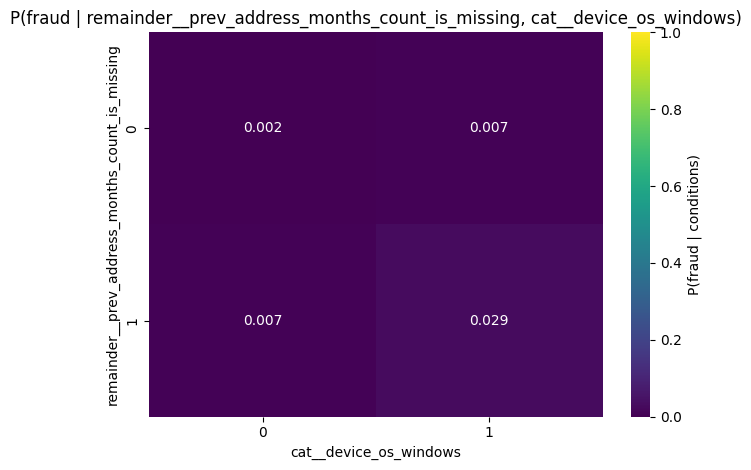

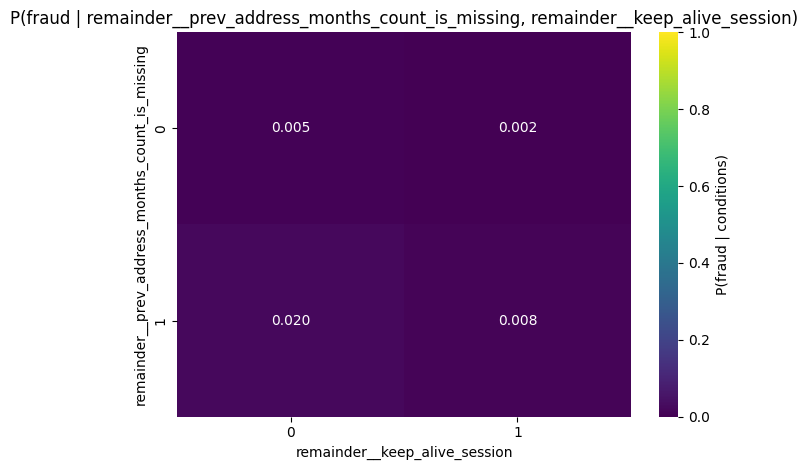

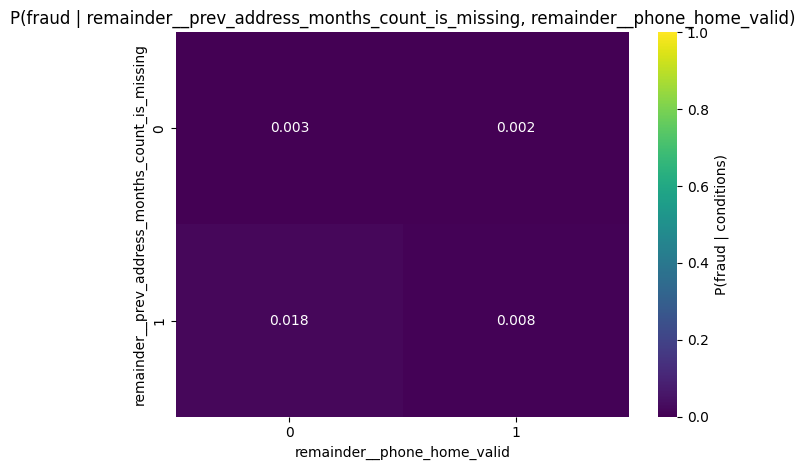

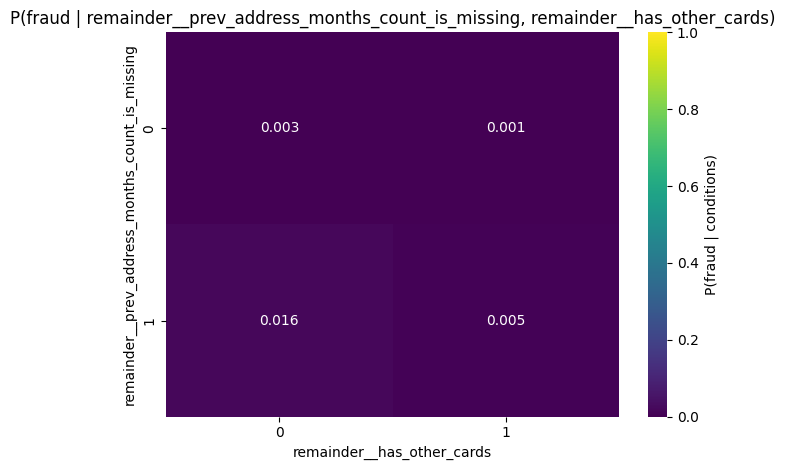

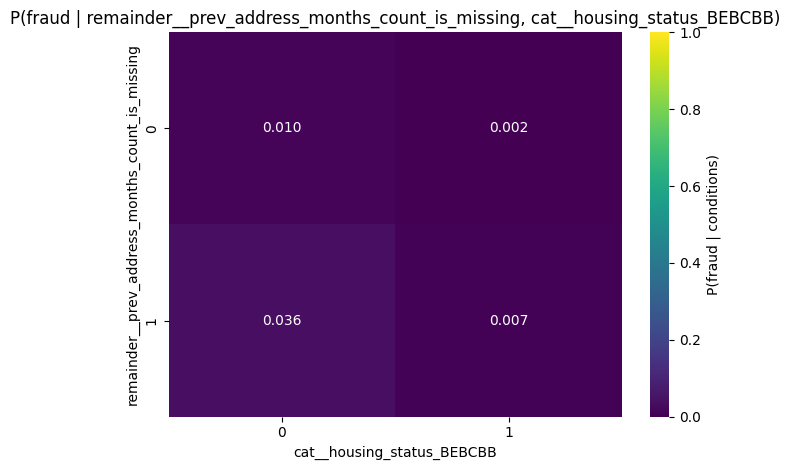

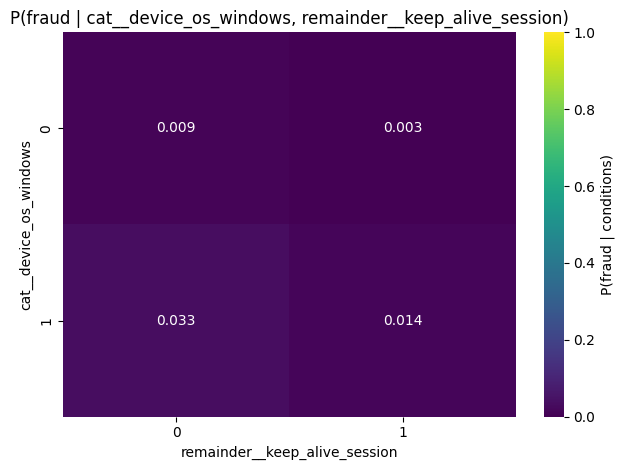

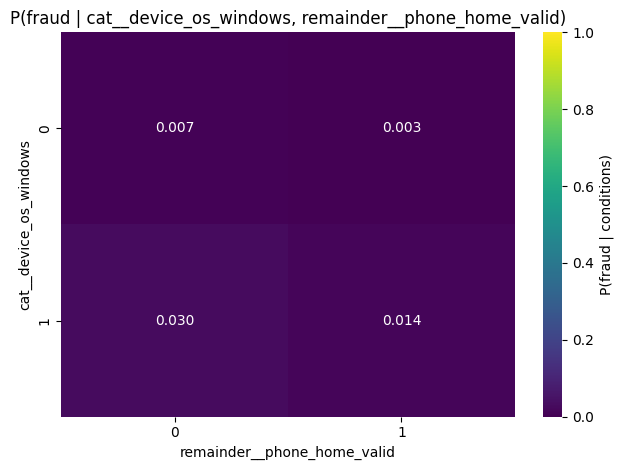

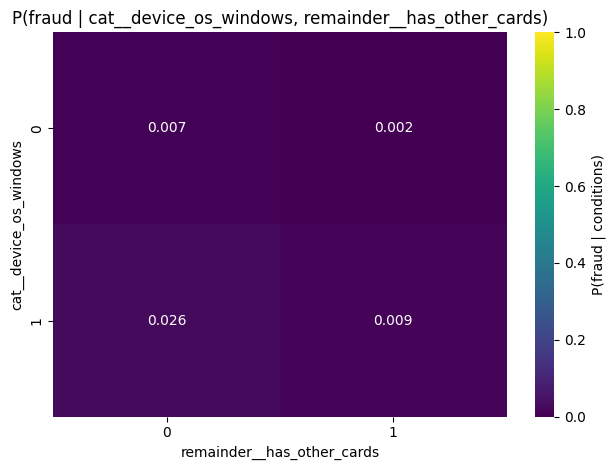

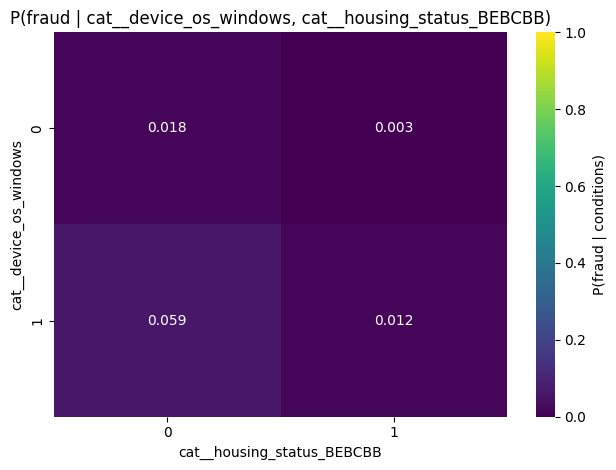

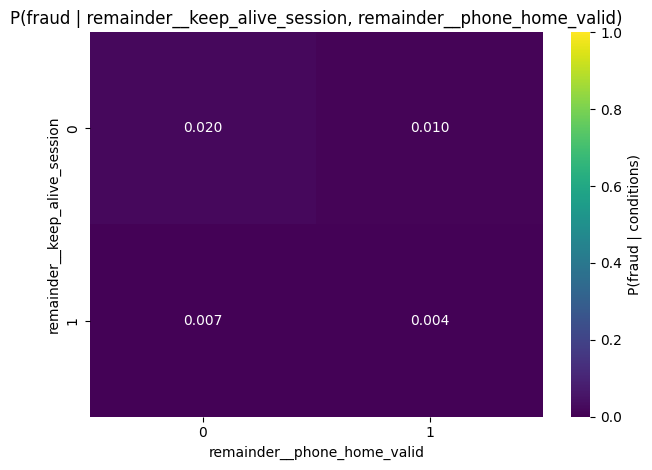

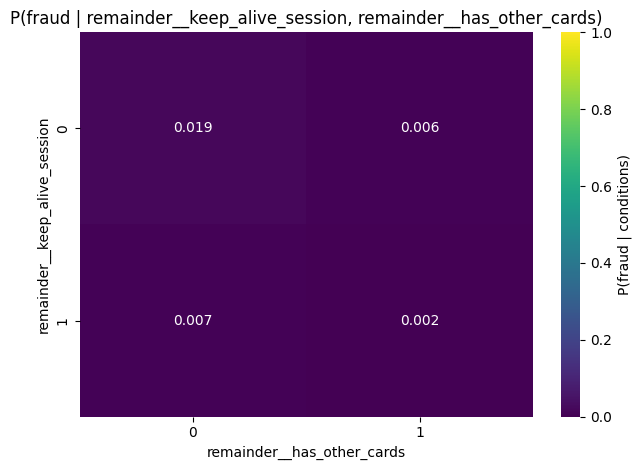

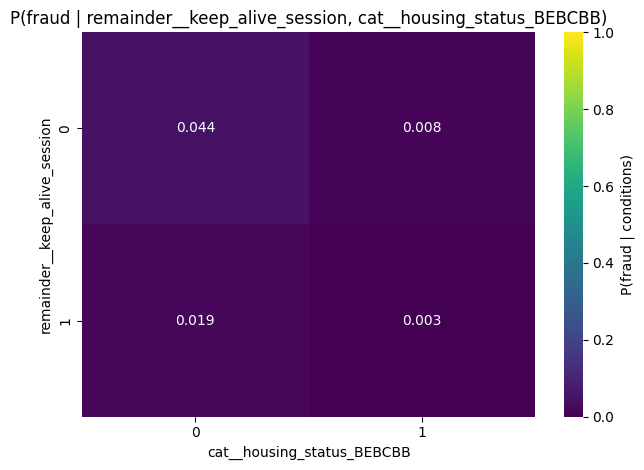

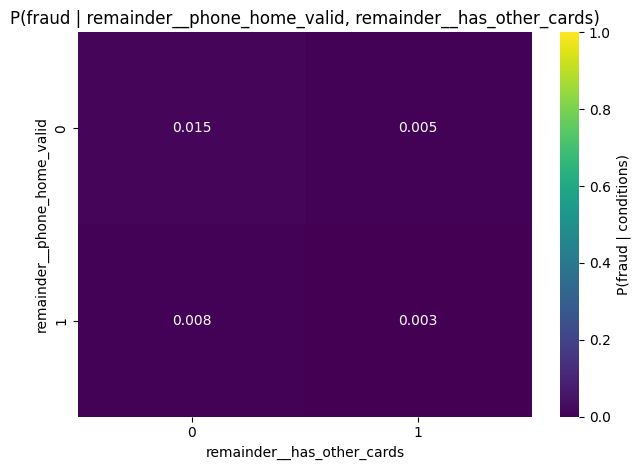

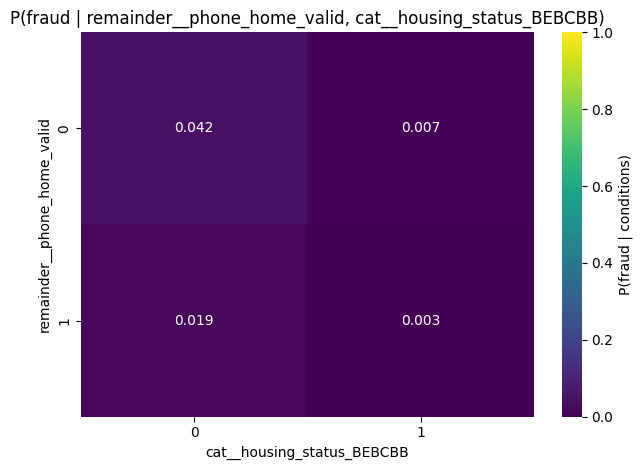

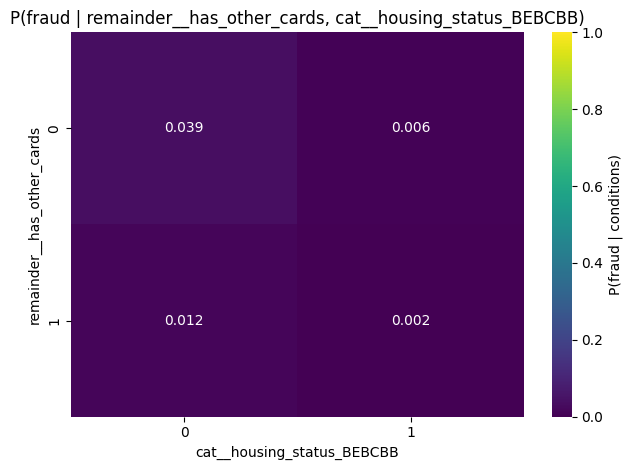

Unconditional fraud rate: 0.010252972053701372


In [17]:
# we use the unstandardized version of X_train_full
X = pd.DataFrame(X_train_full_unstandardized, columns=column_names)
y = y_train_full
X["cat__housing_status_BEBCBB"] = (
    (X["cat__housing_status_BE"] == 1) |
    (X["cat__housing_status_BC"] == 1) |
    (X["cat__housing_status_BB"] == 1)
).astype(int) # we group the columns for housing statuses BE, BC, and BB together since they are one-hot-encoded columns from the same original feature, and their union is therefore meaningful

# this function will help us plot 2x2 binary heat maps
def two_by_two_cond(pair):
  """
  - pair = (feature1, feature2) where feature1 and feature2 are binary features
  - returns a numpy array with shape (2,2), with each value the conditional probability of fraud given the values of feature1 and feature2
  - feature 1 corresponds to row indices and feature 2 corresponds to column indices
  - cells with only one y = 1 example will be set to NaN
  """
  f1, f2 = pair
  out = np.full((2, 2), np.nan)

  for i in (0, 1):
      for j in (0, 1):
          mask = (X[f1] == i) & (X[f2] == j)
          y_subset = y[mask]

          if not(y_subset.sum() <= 1):
              out[i, j] = y_subset.mean()
  return out

"""
Here are the features we will use to create 2x2 heat maps:

remainder__prev_address_months_count_is_missing
cat__device_os_windows
remainder__keep_alive_session
remainder__phone_home_valid
remainder__has_other_cards
cat__housing_status_BEBCBB
"""
# Plot the heat maps
import itertools
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "remainder__prev_address_months_count_is_missing",
    "cat__device_os_windows",
    "remainder__keep_alive_session",
    "remainder__phone_home_valid",
    "remainder__has_other_cards",
    "cat__housing_status_BEBCBB",
]

cmap = sns.color_palette("viridis", as_cmap=True)
cmap.set_bad("lightgray")

for f1, f2 in itertools.combinations(features, 2):
    pair = (f1, f2)

    M = two_by_two_cond(pair)
    df = pd.DataFrame(M, index=["0", "1"], columns=["0", "1"])

    sns.heatmap(
        df,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        vmin=0,
        vmax=1,
        cbar_kws={"label": "P(fraud | conditions)"}
    )

    plt.title(f"P(fraud | {f1}, {f2})")
    plt.xlabel(f2)
    plt.ylabel(f1)
    plt.tight_layout()
    plt.show()

print("Unconditional fraud rate:", y.mean())

In [18]:
# fraud counts for specific feature combinations that have conditional fraud probability >4%

conditions = {
    "BEBCBB=0 & phone_home_valid=0":
        (X["cat__housing_status_BEBCBB"] == 0) &
        (X["remainder__phone_home_valid"] == 0),

    "BEBCBB=0 & keep_alive_session=0":
        (X["cat__housing_status_BEBCBB"] == 0) &
        (X["remainder__keep_alive_session"] == 0),

    "BEBCBB=0 & device_os_windows=1":
        (X["cat__housing_status_BEBCBB"] == 0) &
        (X["cat__device_os_windows"] == 1),
}

for name, mask in conditions.items():
    print(f"{name}: {int(y[mask].sum())} frauds out of {int(mask.sum())} rows")

BEBCBB=0 & phone_home_valid=0: 3491 frauds out of 82665 rows
BEBCBB=0 & keep_alive_session=0: 3259 frauds out of 73423 rows
BEBCBB=0 & device_os_windows=1: 2969 frauds out of 50283 rows


## Observations:
Filtering for regions where conditional probability of fraud is >4%, we observe unusually high conditional probabilities of fraud (around 4-6x higher than the baseline) in the following regions:

- cat__housing_status_BEBCBB == 0 and remainder__phone_home_valid == 0 (Fraud rate = 4.2%)
- cat__housing_status_BEBCBB == 0 and remainder__keep_alive_session == 0 (Fraud rate = 4.4%)
- cat__housing_status_BEBCBB == 0 and cat__device_os_windows == 1 (Fraud rate = 5.9%)

Given that each of these regions corresponds to tens of thousands of data points and thousands of fraud observations, we may be confident that their conditional probabilities are significant assuming no concept drift.

Interestingly, housing status not being among BE, BC, or BB appears as a condition in each of these examples, evidencing the usefulness of this feature in fraud detection. We will therefore include cat__housing_status_BEBCBB as a feature in our performance-focused XGBoost model.